<a href="https://colab.research.google.com/github/DaniloDuque/logistic-regression/blob/main/src/tp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 — Regresión Logística

## Setup

In [1]:
import os, sys

if 'google.colab' in sys.modules:
    if not os.path.exists('logistic-regression'):
        os.system('git clone https://github.com/DaniloDuque/logistic-regression.git')
    os.chdir('logistic-regression')

sys.path.insert(0, os.path.abspath('src'))

---
# Sección 1 — Algoritmo de Regresión Logística

## 1.a — Usar el código del perceptrón como base
DOCUMENTACION EN LATEX: Explique en el reporte cada una de las modificaciones necesarias al código del perceptrón, utilizando como referencia las diferencias entre ambos algoritmos.

### Pruebas unitarias
2 pruebas unitarias (con su objetivo, entradas, salidas esperadas y resultados) para las funciones modificadas en el algoritmo del perceptron base.

---
## 1.b — Experimentos: Datos separables vs no separables

### Imports

In [2]:
# Install spacy
!pip install spacy

# Download the Spanish model
!python -m spacy download es_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 1.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import spacy
from pathlib import Path

from data_generator import generate_data
from logistic_regression import LogisticRegression
from trainer import train_with_history, compute_mae
from metrics import run_experiment, print_single_result, print_runs_table, compute_accuracy
from visualization import plot_results

STEPS = 1000
ALPHA = 0.1

FIGURES_DIR = Path(__file__).parent.parent / 'figures' if '__file__' in dir() else Path('..') / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)


### Experimento 1 — Datos linealmente separables

Dos clases generadas con `cluster_std=1.0` (grupos compactos y bien separados).
Se espera que el modelo converja rápidamente y obtenga un MAE bajo.


Iteraciones: 1000
Caso                           MAE Entren. MAE Prueba Acc Prueba
-----------------------------------------------------------------
Linealmente separable              0.0015     0.0006     1.0000


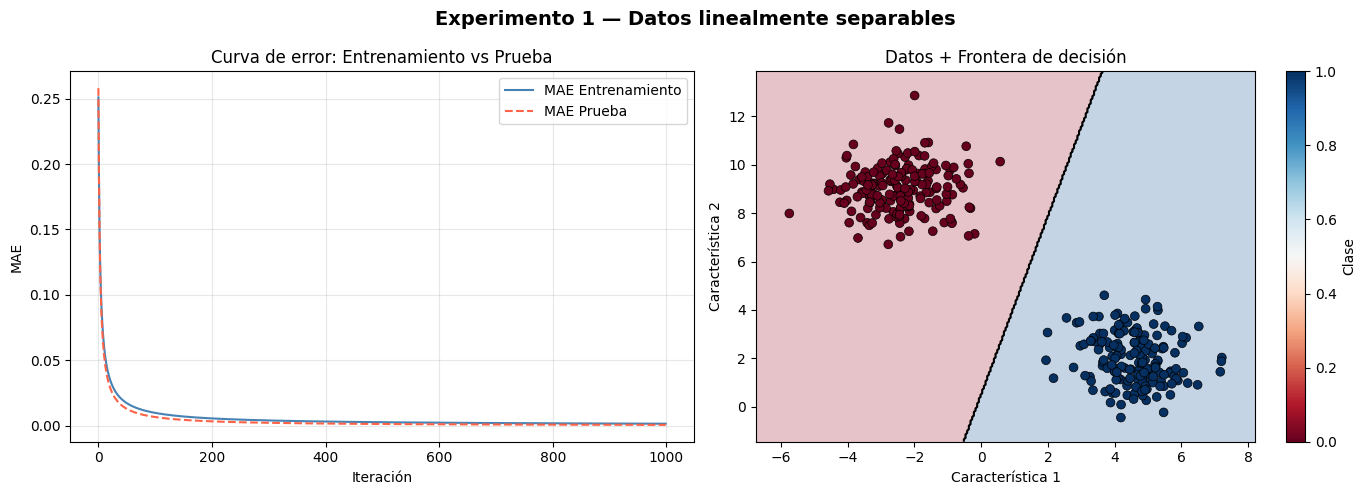

In [4]:
X_train_s, X_test_s, y_train_s, y_test_s = generate_data(separable=True, n_samples=500, random_state=42)

model_s = LogisticRegression(torch.zeros(X_train_s.shape[1], 1))
train_errors_s, test_errors_s = train_with_history(
    model_s, X_train_s, y_train_s, X_test_s, y_test_s, steps=STEPS, alpha=ALPHA
)

mae_train_s = compute_mae(y_train_s, model_s.forward(X_train_s))
mae_test_s  = compute_mae(y_test_s,  model_s.forward(X_test_s))
acc_train_s = compute_accuracy(model_s, X_train_s, y_train_s)
acc_test_s  = compute_accuracy(model_s, X_test_s,  y_test_s)

print(f"Iteraciones: {STEPS}")
print_single_result('Linealmente separable', mae_train_s, mae_test_s, acc_train_s, acc_test_s)

plot_results(model_s, X_train_s, y_train_s, train_errors_s, test_errors_s,
             'Experimento 1 — Datos linealmente separables',
             output_path=FIGURES_DIR / 'experimento1.pdf')


### Experimento 2 — Datos no linealmente separables

Dos clases generadas con `cluster_std=4.0` (grupos solapados).
Se espera que el modelo tenga dificultades y obtenga un MAE más alto.


Iteraciones: 1000
Caso                           MAE Entren. MAE Prueba Acc Prueba
-----------------------------------------------------------------
No linealmente separable           0.1789     0.1403     0.9267


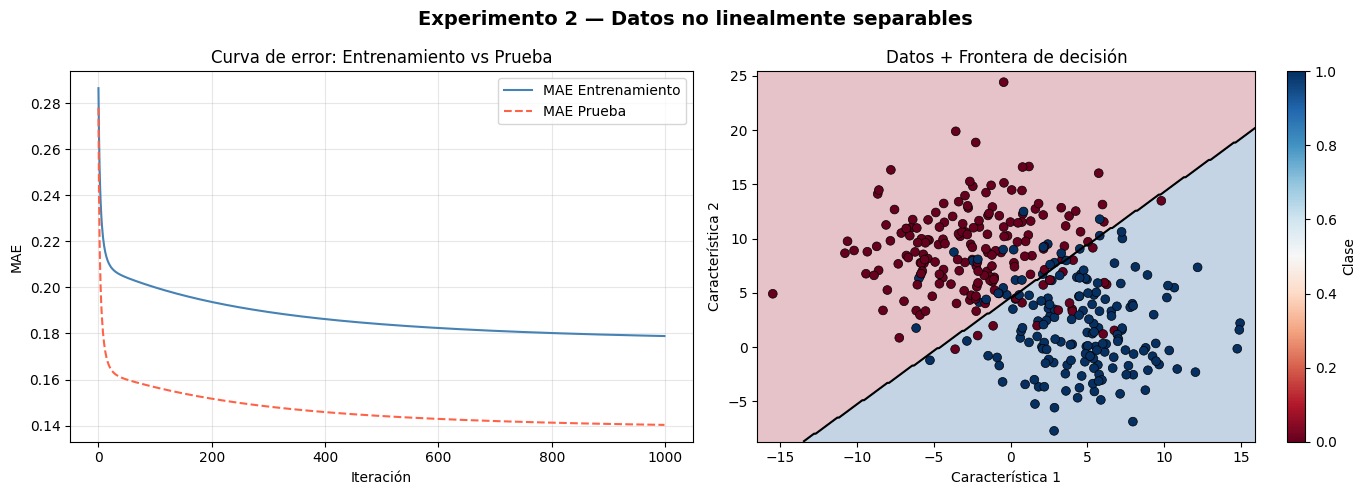

In [5]:
X_train_ns, X_test_ns, y_train_ns, y_test_ns = generate_data(separable=False, n_samples=500, random_state=42)

model_ns = LogisticRegression(torch.zeros(X_train_ns.shape[1], 1))
train_errors_ns, test_errors_ns = train_with_history(
    model_ns, X_train_ns, y_train_ns, X_test_ns, y_test_ns, steps=STEPS, alpha=ALPHA
)

mae_train_ns = compute_mae(y_train_ns, model_ns.forward(X_train_ns))
mae_test_ns  = compute_mae(y_test_ns,  model_ns.forward(X_test_ns))
acc_train_ns = compute_accuracy(model_ns, X_train_ns, y_train_ns)
acc_test_ns  = compute_accuracy(model_ns, X_test_ns,  y_test_ns)

print(f"Iteraciones: {STEPS}")
print_single_result('No linealmente separable', mae_train_ns, mae_test_ns, acc_train_ns, acc_test_ns)

plot_results(model_ns, X_train_ns, y_train_ns, train_errors_ns, test_errors_ns,
             'Experimento 2 — Datos no linealmente separables',
             output_path=FIGURES_DIR / 'experimento2.pdf')


### 1.2 — 10 ejecuciones: MAE medio, precisión, mínimo y máximo


In [6]:
results_s  = run_experiment(separable=True,  steps=STEPS, alpha=ALPHA)
results_ns = run_experiment(separable=False, steps=STEPS, alpha=ALPHA)

print_runs_table(results_s, results_ns)

Caso                          Media Desv.Típ      Mín      Máx
----------------------------------------------------------------------
MAE (prueba)
  Linealmente separable      0.0705   0.1356   0.0005   0.4684
  No linealmente separable   0.2759   0.1300   0.0924   0.4906
----------------------------------------------------------------------
Precisión (prueba)
  Linealmente separable      0.9407   0.1348   0.5400   1.0000
  No linealmente separable   0.7760   0.1368   0.5267   0.9467


---
# Sección 2 — Regresión Logística y LLMs para clasificación de textos

## Pre requisitos


In [7]:
# Prerequisitos
import torch

import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from dataset import load_feina
from logistic_regression import LogisticRegression

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

#!pip install spacy
#!python -m spacy download es_core_news_lg
#import spacy

#!pip install simplemma
#import simplemma

# Cargar dataset de FEINA
df, all_texts, all_labels = load_feina()
#    df         : pd.DataFrame  — dataframe completo
#    texts      : list[str]     — textos (Segment + Proposal concatenados)
#    labels     : list[int]     — 1 = complejo (Segment), 0 = simple (Proposal)


STEPS_LR = 3000

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


FEINA_1.xlsx:   0%|          | 0.00/808k [00:00<?, ?B/s]

Shape:    (5313, 15)
Columnas: ['Unnamed: 0', 'idFinal', 'Segment', 'Proposal', 'idcod', 'atr0', 'atr1', 'atr2', 'atr3', 'atr4', 'atr5', 'atr6', 'atr7', 'atr8', 'lex']
                                             Segment  \
0  Como antes explicamos, las finanzas y los conc...   
1  Una vez dirimidos estos asuntos, se entra de l...   
2  Pero aquí no termina la utilidad del libro, ya...   

                                            Proposal  lex  
0  Como antes explicamos, las finanzas están sust...    0  
1  Una vez resueltos estos asuntos, se abordan al...    1  
2  Pero aquí no termina la utilidad del libro, pu...    0  



#Sección 2.1 - Regresión logística con la TFIDF.

In [8]:
# Preprocesamiento del texto

def preprocess_text(document):
    tokeniser = RegexpTokenizer(r'\w+')
    tokens = tokeniser.tokenize(document)

    lemmatiser = WordNetLemmatizer()
    lemmas = [lemmatiser.lemmatize(token.lower(), pos='v') for token in tokens]

    keywords = [lemma for lemma in lemmas if lemma not in stopwords.words('spanish')]
    return keywords

print("── a) Examen cualitativo del preprocesamiento ──")
for text in all_texts[:3]:
    print(f"  ORIGINAL:  {text}")
    print(f"  PROCESADO: {preprocess_text(text)}")
    print()

── a) Examen cualitativo del preprocesamiento ──
  ORIGINAL:  Como antes explicamos, las finanzas y los conceptos y prácticas que las sustentan no pueden percibirse independientemente o desligadas del contexto económico y de los conceptos que a la vez lo explican; por tal razón es que la entrada al libro, además de la comprensión de la educación financiera, su significado y sus implicaciones, incluye también unos conceptos o nociones básicas referentes e indispensables sobre la Economía.
  PROCESADO: ['explicamos', 'finanzas', 'conceptos', 'prácticas', 'sustentan', 'pueden', 'percibirse', 'independientemente', 'desligadas', 'contexto', 'económico', 'conceptos', 'vez', 'explican', 'tal', 'razón', 'entrada', 'libro', 'además', 'comprensión', 'educación', 'financiera', 'significado', 'implicaciones', 'incluye', 'conceptos', 'nociones', 'básicas', 'referentes', 'indispensables', 'economía']

  ORIGINAL:  Una vez dirimidos estos asuntos, se entra de lleno a algunos aspectos e instrumentos q

In [9]:
# Construcción de descriptores TF-IDF
def display_tfidfs(X_vectorised):
    df_sparse = pd.DataFrame.sparse.from_spmatrix(X_vectorised)
    print(df_sparse)

tfidf_vectoriser = TfidfVectorizer(analyzer=preprocess_text)
corpus_df = pd.DataFrame({'corpus': all_texts})
X_train_vectorised = tfidf_vectoriser.fit_transform(corpus_df['corpus'])

# Examen cualitativo con textos de prueba elegidos del propio dataset
print("── b) Examen cualitativo de descriptores TF-IDF ──")
test_samples = all_texts[6000:6003]
test_vectorised = tfidf_vectoriser.transform(test_samples)
display_tfidfs(test_vectorised)

── b) Examen cualitativo de descriptores TF-IDF ──
   0      1      2      3      4      5      6      7      8      9      ...  \
0      0      0      0      0      0      0      0      0      0      0  ...   
1      0      0      0      0      0      0      0      0      0      0  ...   
2      0      0      0      0      0      0      0      0      0      0  ...   

   12505  12506  12507  12508  12509  12510  12511  12512  12513  12514  
0      0      0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0      0      0  

[3 rows x 12515 columns]


In [10]:
import pandas as pd
import torch
# Transformación a matriz
X_tfidf = pd.DataFrame.sparse.from_spmatrix(X_train_vectorised)
print(f"\n── c) Forma de la matriz TF-IDF: {X_tfidf.shape} ──")  # (N, vocab_size)


X = torch.tensor(X_tfidf.values, dtype=torch.float64)
t = torch.tensor(all_labels, dtype=torch.float64).unsqueeze(1)


── c) Forma de la matriz TF-IDF: (10626, 12515) ──


In [ ]:
# Clasificación con regresión logística

X_train, X_test, t_train, t_test = train_test_split(
    X, t, test_size=0.2, random_state=42
)

model_tfidf = LogisticRegression(
    torch.zeros((X.shape[1], 1), dtype=torch.float64)
)
model_tfidf.train(X_train, t_train, steps=STEPS_LR)


In [13]:
print("\n── d) Resultados ──")
print(f"  Train accuracy: {model_tfidf.accuracy(X_train, t_train):.4f}")
print(f"  Test  accuracy: {model_tfidf.accuracy(X_test,  t_test):.4f}")


── d) Resultados ──
  Train accuracy: 0.7059
  Test  accuracy: 0.5357



#Sección 2.2 - Regresión logística con vectores empotrados de BERT.

### a) Transformar entrada en vectores empotrados


In [14]:



from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"


# ── Modelo 1: BERT en español (dccuchile) ─────────────────────────
tokenizerBERT = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")
modelBERT = AutoModelForMaskedLM.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")
modelBERT.eval()

# ── Modelo 2: BERTIN - RoBERTa en español ─────────────────────────
tokenizerRoBERTa = AutoTokenizer.from_pretrained("bertin-project/bertin-roberta-base-spanish")
modelRoBERTa = AutoModelForMaskedLM.from_pretrained("bertin-project/bertin-roberta-base-spanish")
modelRoBERTa.eval()

# ── Embedding mediante token CLS ──────────────────────────────────
def get_embeddings_batch(texts, model, tokenizer, batch_size=32, device="cpu"):
    model = model.to(device)
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            max_length=512,
            padding=True      # padea al más largo del batch
        ).to(device)

        with torch.no_grad():
            outputs = model.base_model(**inputs)

        # Token CLS de cada elemento del batch → shape (batch_size, 768)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu())

    return torch.cat(all_embeddings, dim=0).numpy()  # (N, 768)


embInputsBERT    = get_embeddings_batch(all_texts, modelBERT,    tokenizerBERT,    device=device)
embInputsRoBERTa = get_embeddings_batch(all_texts, modelRoBERTa, tokenizerRoBERTa, device=device)

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: bertin-project/bertin-roberta-base-spanish
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### b) Entrenar regresor logístico con el dataset empotrado

In [15]:
from logistic_regression import LogisticRegression

STEPS_LR = 10000

#Con BERT
X = torch.tensor(embInputsBERT, dtype=torch.float64)
t = torch.tensor(all_labels, dtype=torch.float64).unsqueeze(1)  # (N,) → (N, 1)

modelB = LogisticRegression(torch.zeros((X.shape[1], 1), dtype=torch.float64))
modelB.train(X, t, STEPS_LR)

#Con RoBERTa
M = torch.tensor(embInputsRoBERTa, dtype=torch.float64)
y = torch.tensor(all_labels, dtype=torch.float64).unsqueeze(1)  # (N,) → (N, 1)

modelR = LogisticRegression(torch.zeros((X.shape[1], 1), dtype=torch.float64))
modelR.train(M, y, STEPS_LR)

### c) Evaluar con los mismos datos de entrenamiento la clasificación que hace entrenado

In [18]:
accB = modelB.accuracy(X, t)
print(f"Accuracy BERT: {accB}")

accR = modelR.accuracy(M, y)
print(f"Accuracy RoBERTa: {accR}")

Accuracy BERT: 0.7042160737812911
Accuracy RoBERTa: 0.6388104648974214


# ─────────────────────────────────────────────────────────────────
# Sección 2.3 — Modelos LLM para clasificación de complejidad
# Modelos:
#   1. Recognai/zeroshot_selectra_medium  (español, ELECTRA-based)
#   2. facebook/bart-large-mnli           (multilingüe, BART-based)
# ─────────────────────────────────────────────────────────────────

In [ ]:
# ── Sección 2.3 — LLMs ───────────────────────────────────────────
from llm_classifier import (
    load_classifiers, classify_all,
    show_examples, compute_llm_metrics, print_metrics_table
)

# Carga
classifiers = load_classifiers()

# 3 ejemplos cualitativos
ejemplos = [
    "El banco ofrece una cuenta de ahorros con interés anual del 3%.",
    "La tasa de rentabilidad ajustada por riesgo refleja la volatilidad "
    "implícita del subyacente en el mercado de derivados.",
    "Puedes guardar tu dinero en el banco y ganar un pequeño porcentaje extra.",
]
show_examples(classifiers, ejemplos)

# Dataset completo — all_texts y all_labels vienen de load_feina()
predictions = classify_all(classifiers, all_texts)
metrics     = compute_llm_metrics(predictions, all_labels)
print_metrics_table(metrics)

### Comentarios — Ejemplos cualitativos

| # | Texto | Selectra | BART | ¿Correcto? |
|---|-------|----------|------|------------|
| 1 | "El banco ofrece una cuenta de ahorros..." | simple (0.69) | complex (0.67) | Selectra ✓ / BART ✗ |
| 2 | "La tasa de rentabilidad ajustada por riesgo..." | complejo (0.91) | complex (0.87) | Ambos ✓ |
| 3 | "Puedes guardar tu dinero en el banco..." | simple (0.79) | simple (0.72) | Ambos ✓ |

**Ejemplo 1:** Ambos modelos muestran baja confianza (~0.69 y ~0.67), lo que
indica que el texto está en una zona fronteriza. Selectra lo clasifica
correctamente como simple, mientras que BART lo etiqueta como complejo,
posiblemente porque procesa español como lengua extranjera y el vocabulario
financiero ("interés anual", "cuenta de ahorros") activa señales de
complejidad.

**Ejemplo 2:** Es el caso más claro — terminología técnica densa
("rentabilidad ajustada por riesgo", "volatilidad implícita", "subyacente",
"derivados") es reconocida como compleja por ambos modelos con alta
confianza (0.91 y 0.87). La coincidencia sugiere que este tipo de
complejidad léxica es robusta incluso entre idiomas.

**Ejemplo 3:** Ambos modelos coinciden en `simple` con confianza moderada.
Esto es esperable dado que el texto usa vocabulario cotidiano y estructura
sintáctica sencilla, a pesar de referirse al mismo tema financiero que el
ejemplo 1 — lo que indica que ambos modelos son sensibles a la complejidad
léxica y no solo al dominio temático.

**Observación general:** Selectra, al estar entrenado en español, muestra
mayor confianza promedio y mejor criterio en casos ambiguos. BART, siendo
un modelo en inglés, puede perder matices semánticos del español, lo que
se refleja en su error en el ejemplo 1.

### Comentarios — Resultados sobre el dataset completo

| Modelo    | Accuracy | MAE    |
|-----------|----------|--------|
| Selectra  | 0.5217   | 0.4783 |
| BART      | 0.4995   | 0.5005 |

Los resultados son sorprendentes y requieren interpretación cuidadosa:

**Rendimiento cercano al azar:** Ambos modelos rondan el 50% de accuracy,
que es exactamente lo que obtendría un clasificador aleatorio en un dataset
balanceado. Esto contrasta con el buen desempeño observado en los 3 ejemplos
cualitativos, donde ambos modelos mostraban confianza razonable.

**BART por debajo del azar:** Con accuracy de 0.4995 y MAE de 0.5005, BART
está esencialmente invirtiendo las etiquetas — clasifica como `complex` lo
que es simple y viceversa. Esto sugiere que sus labels en inglés
("simple" / "complex") no se alinean bien con las etiquetas del dataset
cuando se procesa texto en español a escala.

**Selectra apenas supera el azar:** A pesar de estar entrenado en español,
0.5217 es un margen marginal sobre el 50%. Esto indica que la tarea de
clasificación del dataset FEINA no se alinea bien con los labels
"simple" / "complejo" usados en el zero-shot, o que el criterio de
complejidad del dataset difiere del que el modelo asume intrínsecamente.

**Causa probable:** Ambos modelos son zero-shot, es decir, no fueron
entrenados específicamente para esta tarea. La definición de "complejo"
en FEINA (simplificación lexical de textos) puede diferir significativamente
de lo que estos modelos asocian con complejidad textual general.

**Conclusión:** Para esta tarea específica, los LLMs zero-shot no superan
una línea base aleatoria, lo que refuerza el valor de los enfoques
supervisados como la regresión logística con TF-IDF o embeddings de BERT,
que tienen acceso directo a las etiquetas del dataset durante el
entrenamiento.

# Sección 2.4 Modelos LLM con few shot

In [ ]:
# Few-Shot LLMs
from few_shot_classifier import (
    load_few_shot_classifiers, classify_all_configs,
    show_few_shot_examples, compute_few_shot_metrics,
    print_few_shot_metrics
)

# Carga (reutiliza los mismos modelos que la sección anterior)
classifiers = load_few_shot_classifiers()

# 3 ejemplos cualitativos
ejemplos = [
    "El banco ofrece una cuenta de ahorros con interés anual del 3%.",
    "La tasa de rentabilidad ajustada por riesgo refleja la volatilidad "
    "implícita del subyacente en el mercado de derivados.",
    "Puedes guardar tu dinero en el banco y ganar un pequeño porcentaje extra.",
]
show_few_shot_examples(classifiers, ejemplos)

# Dataset completo
results = classify_all_configs(classifiers, all_texts)
metrics = compute_few_shot_metrics(results, all_labels)
print_few_shot_metrics(metrics)


Modelo                Config                     Acc     MAE

selectra              1shot_newline           0.4999  0.5001
selectra              3shot_newline           0.5039  0.4961
selectra              5shot_newline           0.4894  0.5106
bart                  1shot_newline           0.4992  0.5008
bart                  3shot_newline           0.5003  0.4997
bart                  5shot_newline           0.5000  0.5000
